# Model Comparison — Pass/Fail Prediction

Compares the three models on the **same** train/test split: Logistic Regression, XGBoost and the MLP.

For the full wandb logging (confusion matrices + ROC curves per model) run from the `part3/` folder:

```bash
poetry run python -m src.train
```

This notebook reproduces the metrics in-process for a quick side-by-side table and chart.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys

# Make the part3/ package importable and data/ paths resolvable from notebooks/.
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from src.features import build_dataset, build_full_xy
from src.metrics import compute_metrics, evaluate_cv, sweep_cost_threshold
from src.models.sklearn_models import build_dummy, build_logreg, build_xgboost

with open("config.yaml") as f:
    config = yaml.safe_load(f)

# Shared single split (used for the MLP and the quick side-by-side below) ...
dataset = build_dataset(config)
# ... plus the full, unsplit matrix for the stratified cross-validation further down.
X_full, y_full, feature_names = build_full_xy(config)

print(f"features={dataset.input_dim}  train={len(dataset.y_train)}  test={len(dataset.y_test)}")
print(f"full set: n={len(y_full)}  pass rate={y_full.mean():.2f}")

Loading and cleaning quiz data for SemesterX...
Loading and cleaning exam data for SemesterX...
Merging quiz and exam data for SemesterX...
Loading and cleaning quiz data for SemesterY...
Loading and cleaning exam data for SemesterY...
Merging quiz and exam data for SemesterY...
Loading and cleaning quiz data for SemesterX...


C:\FHNW_Programmiersachen\8_sem\P-BI-MMI\part3\src\features.py:90: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


Loading and cleaning exam data for SemesterX...
Merging quiz and exam data for SemesterX...
Loading and cleaning quiz data for SemesterY...
Loading and cleaning exam data for SemesterY...
Merging quiz and exam data for SemesterY...
features=10  train=108  test=27
full set: n=135  pass rate=0.67


C:\FHNW_Programmiersachen\8_sem\P-BI-MMI\part3\src\features.py:139: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


## Logistic Regression & XGBoost

In [2]:
results = {}

for name, build_fn in [("LogisticRegression", build_logreg), ("XGBoost", build_xgboost)]:
    # Factories take (config, y_train) -> XGBoost derives scale_pos_weight from it.
    model = build_fn(config, dataset.y_train)
    model.fit(dataset.X_train, dataset.y_train)
    y_pred = model.predict(dataset.X_test)
    y_prob = model.predict_proba(dataset.X_test)[:, 1]
    results[name] = compute_metrics(dataset.y_test, y_pred, y_prob)

results

C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


{'LogisticRegression': {'accuracy': 0.5925925925925926,
  'precision': 0.8888888888888888,
  'recall': 0.4444444444444444,
  'f1': 0.5925925925925926,
  'roc_auc': 0.7345679012345678},
 'XGBoost': {'accuracy': 0.5555555555555556,
  'precision': 0.7142857142857143,
  'recall': 0.5555555555555556,
  'f1': 0.625,
  'roc_auc': 0.5462962962962963}}

## MLP

In [3]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from src.datamodule import QuizDataModule
from src.models.mlp import QuizMLPClassifier

dm = QuizDataModule(config, dataset=dataset)
dm.setup("fit")

# Balanced class weights for the loss (same as src/train.py) to counter imbalance.
class_weights = None
if config["models"]["mlp"].get("class_weight") == "balanced":
    class_weights = compute_class_weight(
        "balanced", classes=np.array([0, 1]), y=dataset.y_train
    )

mlp = QuizMLPClassifier(input_dim=dm.input_dim, config=config, class_weights=class_weights)

callbacks = []
if config["models"]["mlp"].get("early_stopping", False):
    callbacks.append(EarlyStopping(monitor="val_loss",
                                   patience=config["models"]["mlp"].get("patience", 5)))

trainer = pl.Trainer(max_epochs=config["trainer"]["max_epochs"], logger=False,
                     enable_checkpointing=False, enable_progress_bar=False,
                     callbacks=callbacks)
trainer.fit(mlp, datamodule=dm)
trainer.test(mlp, datamodule=dm)

results["MLP"] = compute_metrics(
    np.array(mlp.test_targets), np.array(mlp.test_preds), np.array(mlp.test_probs)
)
results["MLP"]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type             | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | network        | Sequential       | 210    | train | 0    
1 | loss_fn        | CrossEntropyLoss | 0      | train | 0    
2 | train_a

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.6296296119689941
         test_f1            0.7195767164230347
        test_loss           0.7070421576499939
     test_precision          0.654321014881134
       test_recall          0.8395061492919922
      test_roc_auc          0.14814814925193787
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


{'accuracy': 0.6296296296296297,
 'precision': 0.6538461538461539,
 'recall': 0.9444444444444444,
 'f1': 0.7727272727272727,
 'roc_auc': 0.41975308641975306}

## Comparison table & chart

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.593,0.889,0.444,0.593,0.735
XGBoost,0.556,0.714,0.556,0.625,0.546
MLP,0.630,0.654,0.944,0.773,0.420


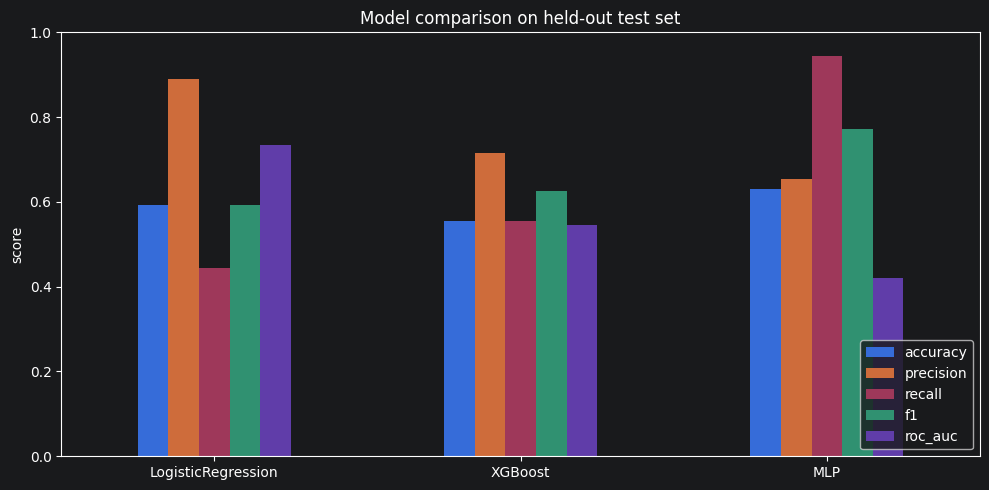

In [4]:
comparison = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "roc_auc"]]
display(comparison.style.format("{:.3f}").background_gradient(cmap="Greens"))

comparison.plot.bar(figsize=(10, 5))
plt.title("Model comparison on held-out test set")
plt.ylabel("score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Stratified cross-validation (the reliable comparison)

A single 27-row test split is too small and noisy to rank models on this dataset. Below we evaluate with `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` and `cross_val_predict(..., method="predict_proba")`, building **one confusion matrix and AUC on the pooled out-of-fold predictions** and reporting **per-fold AUC and cost as mean ± std**.

The two `DummyClassifier` baselines (`most_frequent`, `stratified`) set the floor every real model must beat. The MLP isn't a drop-in sklearn estimator, so it gets the **same** stratified folds via a small manual loop (next-but-one cell) and lands in the same comparison table.

In [5]:
# Stratified 5-fold CV on the FULL set. Each model is scored on pooled out-of-fold
# predictions (one confusion matrix + AUC over every student) plus per-fold AUC
# and expected-cost mean ± std. Far more reliable than a single 27-row test split.
n_splits = config.get("cv", {}).get("n_splits", 5)
random_state = config["data"].get("random_state", 42)

# Cost orientation (see config.yaml): positive class = passed, so the expensive
# error (missing a failing student) is a FALSE POSITIVE.
cost_cfg = config.get("cost", {})
c_fp = cost_cfg.get("false_positive", 5.0)   # missed at-risk student (predict pass, actually fail)
c_fn = cost_cfg.get("false_negative", 1.0)   # false alarm (predict fail, actually pass)

cv_models = {
    "Dummy (most_frequent)": build_dummy(config, y_full, strategy="most_frequent"),
    "Dummy (stratified)": build_dummy(config, y_full, strategy="stratified"),
    "LogisticRegression": build_logreg(config, y_full),
    "XGBoost": build_xgboost(config, y_full),
}

cv_results = {}
for name, est in cv_models.items():
    cv_results[name] = evaluate_cv(
        est, X_full, y_full, n_splits=n_splits, random_state=random_state,
        cost_fp=c_fp, cost_fn=c_fn,
    )

print(f"StratifiedKFold(n_splits={n_splits}, shuffle=True, random_state={random_state})")
print(f"costs: false_positive(missed at-risk)={c_fp}  false_negative(false alarm)={c_fn}")

C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its defau

StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
costs: false_positive(missed at-risk)=5.0  false_negative(false alarm)=1.0


In [6]:
# The MLP isn't a drop-in sklearn estimator, so we run the SAME stratified CV by
# hand: per fold, scale on the training rows only, train a fresh class-weighted MLP
# (with early stopping), and collect its held-out probabilities. Returns the same
# dict shape as evaluate_cv so it slots straight into the tables below.
from src.features import Dataset as SplitDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score
from src.metrics import expected_cost


def mlp_cross_val(config, X, y, feature_names, n_splits, random_state, cost_fp, cost_fn):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    mlp_cfg = config["models"]["mlp"]
    oof_prob = np.zeros(len(y), dtype=float)
    fold_aucs, fold_costs = [], []

    for tr, te in cv.split(X, y):
        scaler = StandardScaler().fit(X[tr])
        Xtr = scaler.transform(X[tr]).astype("float32")
        Xte = scaler.transform(X[te]).astype("float32")
        ytr, yte = y[tr], y[te]

        fold_ds = SplitDataset(X_train=Xtr, X_test=Xte, y_train=ytr, y_test=yte,
                               feature_names=feature_names, scaler=scaler)
        dm = QuizDataModule(config, dataset=fold_ds)
        dm.setup("fit")

        cw = None
        if mlp_cfg.get("class_weight") == "balanced":
            cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=ytr)
        model = QuizMLPClassifier(input_dim=dm.input_dim, config=config, class_weights=cw)

        cbs = []
        if mlp_cfg.get("early_stopping", False):
            cbs.append(EarlyStopping(monitor="val_loss", patience=mlp_cfg.get("patience", 5)))
        trainer = pl.Trainer(max_epochs=config["trainer"]["max_epochs"], logger=False,
                             enable_checkpointing=False, enable_progress_bar=False,
                             enable_model_summary=False, accelerator="cpu", callbacks=cbs)
        trainer.fit(model, datamodule=dm)
        trainer.test(model, datamodule=dm, verbose=False)

        prob = np.array(model.test_probs)  # test loader is unshuffled -> aligns with te
        oof_prob[te] = prob
        if len(np.unique(yte)) > 1:
            fold_aucs.append(roc_auc_score(yte, prob))
        tn, fp, fn, tp = confusion_matrix(yte, (prob >= 0.5).astype(int), labels=[0, 1]).ravel()
        fold_costs.append(expected_cost(tn, fp, fn, tp, cost_fp, cost_fn))

    oof_pred = (oof_prob >= 0.5).astype(int)
    cm = confusion_matrix(y, oof_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "pooled_metrics": compute_metrics(y, oof_pred, oof_prob),
        "confusion_matrix": cm,
        "oof_prob": oof_prob,
        "oof_pred": oof_pred,
        "fold_aucs": fold_aucs,
        "auc_mean": float(np.mean(fold_aucs)) if fold_aucs else float("nan"),
        "auc_std": float(np.std(fold_aucs)) if fold_aucs else float("nan"),
        "pooled_cost": expected_cost(tn, fp, fn, tp, cost_fp, cost_fn),
        "fold_costs": fold_costs,
        "cost_mean": float(np.mean(fold_costs)),
        "cost_std": float(np.std(fold_costs)),
    }


cv_results["MLP"] = mlp_cross_val(config, X_full, y_full, feature_names,
                                  n_splits, random_state, c_fp, c_fn)
print("MLP CV: AUC = %.3f ± %.3f | cost = %.3f ± %.3f" % (
    cv_results["MLP"]["auc_mean"], cv_results["MLP"]["auc_std"],
    cv_results["MLP"]["cost_mean"], cv_results["MLP"]["cost_std"]))

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\pytorch_lightning\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\pytorch_lig

MLP CV: AUC = 0.580 ± 0.216 | cost = 1.244 ± 0.401


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


In [7]:
# One comparison table over all models. Pooled out-of-fold metrics, plus per-fold
# AUC and expected-cost as mean ± std (n_splits folds). Note the inversion the
# rubric asks for: a dummy can win on accuracy yet lose badly on cost.
def _summary_row(r):
    m = r["pooled_metrics"]
    return {
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "roc_auc": m.get("roc_auc", float("nan")),
        "auc_mean": r["auc_mean"],
        "auc_std": r["auc_std"],
        "cost_mean": r.get("cost_mean", float("nan")),
        "cost_std": r.get("cost_std", float("nan")),
    }

cv_table = pd.DataFrame({name: _summary_row(r) for name, r in cv_results.items()}).T
cv_table = cv_table[["accuracy", "precision", "recall", "f1", "roc_auc",
                     "auc_mean", "auc_std", "cost_mean", "cost_std"]]

print("per-fold mean ± std across folds:")
for name, r in cv_results.items():
    print(f"  {name:24s} AUC {r['auc_mean']:.3f} ± {r['auc_std']:.3f}"
          f"   cost {r.get('cost_mean', float('nan')):.3f} ± {r.get('cost_std', float('nan')):.3f}")

display(
    cv_table.style.format("{:.3f}")
    .background_gradient(cmap="Greens", subset=["roc_auc", "auc_mean"])
    .background_gradient(cmap="Reds_r", subset=["cost_mean"])
)

per-fold mean ± std across folds:
  Dummy (most_frequent)    AUC 0.500 ± 0.000   cost 1.630 ± 0.074
  Dummy (stratified)       AUC 0.510 ± 0.038   cost 1.356 ± 0.104
  LogisticRegression       AUC 0.617 ± 0.127   cost 1.059 ± 0.297
  XGBoost                  AUC 0.606 ± 0.138   cost 0.985 ± 0.286
  MLP                      AUC 0.580 ± 0.216   cost 1.244 ± 0.401


,accuracy,precision,recall,f1,roc_auc,auc_mean,auc_std,cost_mean,cost_std
Dummy (most_frequent),0.674,0.674,1.000,0.805,0.500,0.500,0.000,1.630,0.074
Dummy (stratified),0.593,0.680,0.747,0.712,0.510,0.510,0.038,1.356,0.104
LogisticRegression,0.563,0.716,0.582,0.642,0.580,0.617,0.127,1.059,0.297
XGBoost,0.578,0.736,0.582,0.650,0.564,0.606,0.138,0.985,0.286
MLP,0.585,0.692,0.692,0.692,0.559,0.580,0.216,1.244,0.401


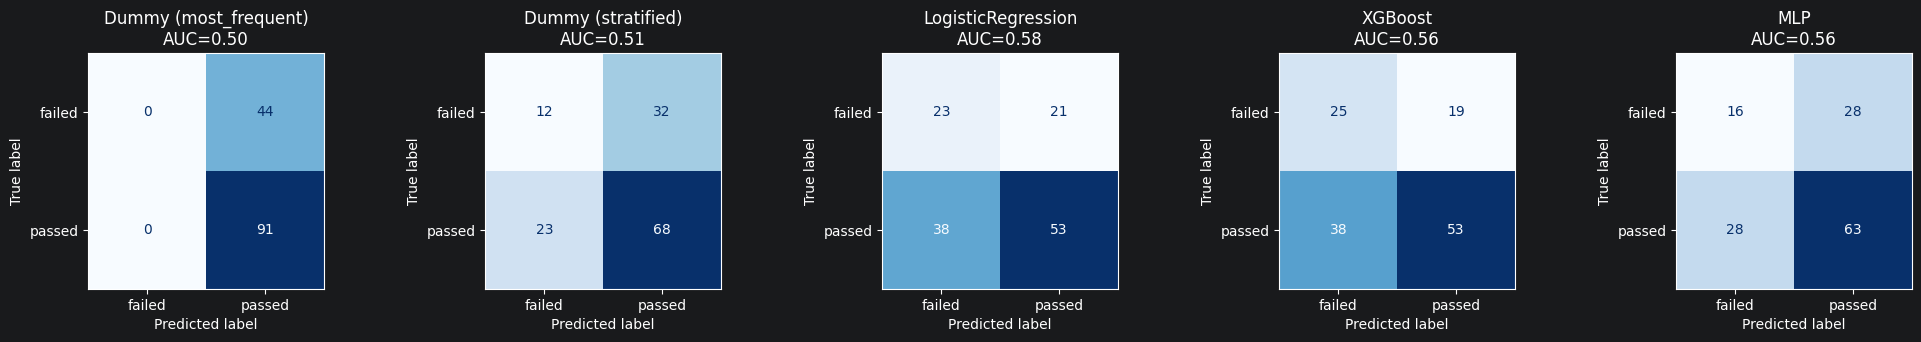

In [8]:
# Pooled out-of-fold confusion matrices (every student predicted from its held-out fold).
n = len(cv_results)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
for ax, (name, r) in zip(np.atleast_1d(axes), cv_results.items()):
    ConfusionMatrixDisplay(r["confusion_matrix"], display_labels=["failed", "passed"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{name}\nAUC={r['pooled_metrics'].get('roc_auc', float('nan')):.2f}")
plt.tight_layout()
plt.show()

## Cost-sensitive evaluation & threshold selection

Accuracy and AUC treat both error types as equal. For an early-warning system they are not: **missing a student who will fail is far worse than a false alarm.** Since the positive class is `passed`, a missed at-risk student is a **false positive** (predict pass, actually fail) — so we weight FP `5×` FN (`config.yaml -> cost`).

We score each model by **expected cost per student** on the pooled out-of-fold predictions, then **sweep the decision threshold** to find the cost-minimising operating point. With asymmetric costs the optimum is *not* 0.5. This is where the dummy baselines fall apart: "predict everyone passes" has decent accuracy but misses every failing student, so its cost is the worst of the lot.

# Cost-sensitive evaluation on the pooled out-of-fold probabilities.
# c_fp / c_fn were defined with the CV above (FP = missed at-risk student >> FN).
print(f"costs: false_positive(missed at-risk)={c_fp}  false_negative(false alarm)={c_fn}")

cost_rows = {}
sweeps = {}
for name, r in cv_results.items():
    sweep = sweep_cost_threshold(y_full, r["oof_prob"], cost_fp=c_fp, cost_fn=c_fn)
    sweeps[name] = sweep
    cost_rows[name] = {
        "cost@0.5": sweep["cost_at_0.5"],
        "best_threshold": sweep["best_threshold"],
        "best_cost": sweep["best_cost"],
        "saving_vs_0.5": sweep["cost_at_0.5"] - sweep["best_cost"],
    }

cost_table = pd.DataFrame(cost_rows).T.sort_values("best_cost")
display(cost_table.style.format("{:.3f}").background_gradient(cmap="Reds_r", subset=["best_cost", "cost@0.5"]))

# Expected cost vs decision threshold (lower is better); marker = cost-min threshold.
plt.figure(figsize=(9, 5))
for name, sweep in sweeps.items():
    ts, costs = zip(*sweep["sweep"])
    line, = plt.plot(ts, costs, label=name)
    plt.scatter([sweep["best_threshold"]], [sweep["best_cost"]], color=line.get_color(), zorder=5)
plt.axvline(0.5, color="grey", ls="--", lw=1, label="default 0.5")
plt.xlabel("decision threshold (predict 'pass' if P(pass) >= t)")
plt.ylabel("expected cost per student")
plt.title(f"Cost vs threshold (FP={c_fp} missed at-risk, FN={c_fn} false alarm)")
plt.legend()
plt.tight_layout()
plt.show()

## Model interpretation — which quiz behaviours predict passing

The logistic regression uses `penalty: l1`, which sets uninformative coefficients to exactly **zero** — so the non-zero coefficients below are the features the model actually relies on, and their **sign** says whether the behaviour pushes a student toward passing (+) or failing (−). On standardised features the magnitude is directly comparable across features. This is the business-readable answer to *"what early quiz behaviour flags an at-risk student?"*

L1 logreg (penalty=l1, C=0.5, class_weight=balanced): 7/10 features survived, 3 zeroed out


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,feature,coefficient
0,mdm_Duration_minutes_sum,-0.340
1,mdm_Score/10.00_mean,0.324
2,statistics_Attempts,0.220
3,regression_Duration_minutes_mean,0.180
4,mdm_Attempts,0.163
5,statistics_Duration_minutes_sum,-0.068
6,evaluation_Duration_minutes_sum,0.024
7,statistics_Score/10.00_mean,0.000
8,predictive_analytics_Score/10.00_min,0.000
9,predictive_analytics_Attempts,0.000


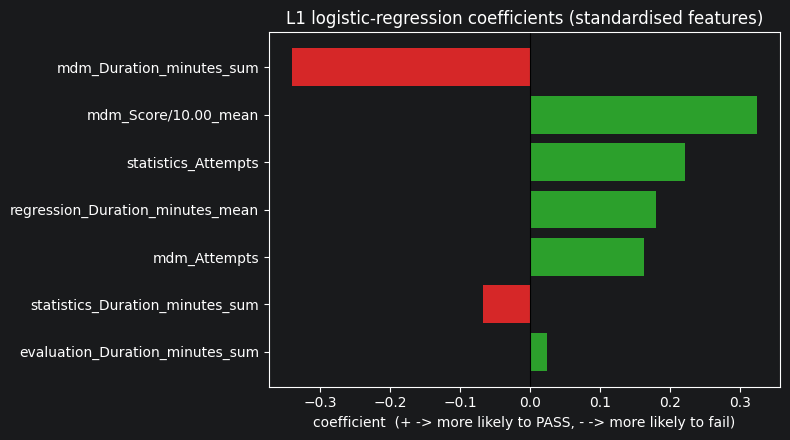

In [12]:
# L1 logistic regression drives weak coefficients to exactly zero, so the surviving
# features ARE the selected ones. Fit on the full standardised set for stable
# coefficients; sign = direction of effect on the log-odds of PASSING.
from sklearn.preprocessing import StandardScaler

scaler_full = StandardScaler().fit(X_full)
logreg_full = build_logreg(config, y_full)
logreg_full.fit(scaler_full.transform(X_full), y_full)

coefs = (
    pd.DataFrame({"feature": feature_names, "coefficient": logreg_full.coef_[0]})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)
lr_cfg = config["models"]["logreg"]
n_kept = int((coefs["coefficient"] != 0).sum())
print(f"L1 logreg (penalty={lr_cfg['penalty']}, C={lr_cfg['C']}, class_weight={lr_cfg['class_weight']}): "
      f"{n_kept}/{len(feature_names)} features survived, {len(feature_names) - n_kept} zeroed out")
display(
    coefs[["feature", "coefficient"]].style.format({"coefficient": "{:.3f}"})
    .background_gradient(cmap="RdBu", subset=["coefficient"], vmin=-coefs["abs_coef"].max(), vmax=coefs["abs_coef"].max())
)

nz = coefs[coefs["coefficient"] != 0].iloc[::-1]
plt.figure(figsize=(8, 0.5 * len(nz) + 1))
plt.barh(nz["feature"], nz["coefficient"],
         color=["#2ca02c" if c > 0 else "#d62728" for c in nz["coefficient"]])
plt.axvline(0, color="k", lw=0.8)
plt.title("L1 logistic-regression coefficients (standardised features)")
plt.xlabel("coefficient  (+ -> more likely to PASS, - -> more likely to fail)")
plt.tight_layout()
plt.show()

## Why each model is a good / bad choice

- **Logistic Regression** — strong, interpretable baseline; with L1 the non-zero coefficients double as the selected features and show *which quiz behaviours* drive pass/fail. Weak if the boundary is non-linear or features interact heavily.
- **XGBoost** — captures non-linearities and feature interactions, handles correlated/unscaled features well; usually the best on small tabular data, but can overfit a small dataset and is less interpretable.
- **MLP** — flexible function approximator, but with only ~135 students it tends to overfit and rarely beats gradient boosting; needs careful regularisation (dropout, class weights, early stopping) and more data to shine.

### Bottom line for the report

- **Accuracy is misleading here.** The `most_frequent` dummy has the *highest* accuracy (it just predicts "pass" for everyone) yet the *worst* expected cost, because it misses every at-risk student. Ranking by **expected cost** flips the order — that is the whole point of the cost matrix.
- **The threshold is a modelling decision.** With FP (missed at-risk student) weighted 5× FN, the cost-minimising threshold is far from 0.5, and choosing it cuts expected cost substantially below the default.
- **Trust the cross-validated numbers, not the single 27-row split.** We report AUC and cost as mean ± std over 5 stratified folds; the single-split table at the top is only a quick look.
- **Honest caveat.** AUC ≈ 0.58–0.62 means the quiz features are only weakly predictive; at the cost-optimal threshold the best model barely edges the trivial "flag everyone as at-risk" rule. The realistic conclusion is *more/earlier signal is needed*, not that any model is production-ready.